In [1]:
# Titanic : Machine Learning from Disaster

-The sinking of Titanic is one of the most notorious shipwrecks in the history. In 1912, during her voyage, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 passengers and crew.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot") # tablo stilini değiştiriyor farklı bir şey de kullanabilirsin.
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/Data Science ve Veri Bilimi/Titanic Project/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

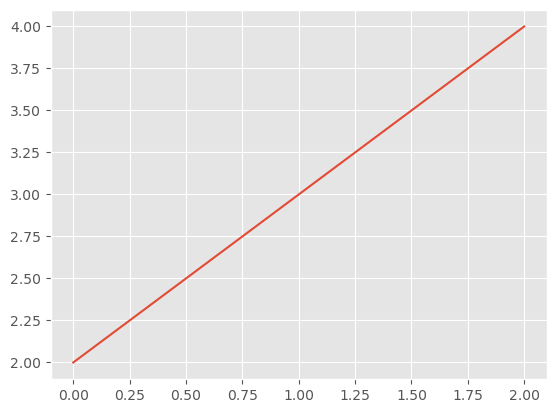

In [5]:
a=[2,3,4]
plt.plot(a)
plt.show()

In [6]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

# Load and Check Data

In [8]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
test_PassengerId = test_df["PassengerId"]
# test_df üzerinde çok fazla işlem yapıcaz. Passenger ıd'nın değişmesini istemediğimiz için bunu farklı bir yere de kaydettik . Kullanıcaz

In [10]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [15]:
train_df.head()  #Fare : Ödenen para  Embarked : Binilecek liman Sex : Cinsiyet

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



# Variable Description
- Bu bölümde bulunan featurların hepsi tek tek açıklanacaktır.
1. PassengerId: unique id number to each passenger ( yolcu numarası)
1. Survived: passenger survive(1) or died(0) ( 0:ölmüş 1 : yaşıyor)
1. Pclass: passenger class ( 3 sınıf yolcu var )
1. Name: name
1. Sex: gender of passenger 
1. Age: age of passenger 
1. SibSp: number of siblings/spouses ( kardeş - eş durumu)
1. Parch: number of parents/children  ( gemide annesi babası ya da cocugu varsa 1 yoksa 0 )
1. Ticket: ticket number 
1. Fare: amount of money spent on ticket
1. Cabin: cabin category
1. Embarked: port where passenger embarked (C = Cherbourg, Q = Queenstown, S = Southampton)


In [18]:
train_df.info() # 891 yolcu var

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* float64(2): Fare ve Age
* int64(5): Pclass, sibsp, parch, passengerId and survived
* object(5): Cabin, embarked, ticket, name and sex

In [21]:
#Feature incelemesi yaptık

# Univariate Variable Analysis
* Categorical Variable: Survived, Sex, Pclass, Embarked, Cabin, Name, Ticket, Sibsp and Parch ( 2 veya daha fazla kategoriden oluşan featurlardır.) Ex : Kaç tane sibsp kategorisiine sahiiniz mesela bunu incelemek için kategorik feature analizi yapıyoruz.
* Numerical Variable: Fare, age and passengerId
* Featurları ilk olarak tek tek inceleyeceğiz. Daha sonra beraber inceleyip aralarındaki ilişkilere bakacağız.



## Categorical Variable

In [25]:
# Metot oluşturacağız. var adlı bir değişken ile variableları ona eşitleyeceğiz. 

In [27]:
def bar_plot(variable):
    """
        input: variable ex: "Sex"
        output: bar plot & value count
    """
    # get feature
    var = train_df[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts() # cinsiyetimizden kaç tane olması gerektiğini sayıyor gibi...
    # var : -male -female - male - male -female- female - female -male   var value counts : 4 :m  4 :f 
    # hangi kategoriden kaç tane olduğunu ve kaç kategori olduğunu öğrenebiliez bu şekilde


    
    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

# bu metodu kullanıcaz 

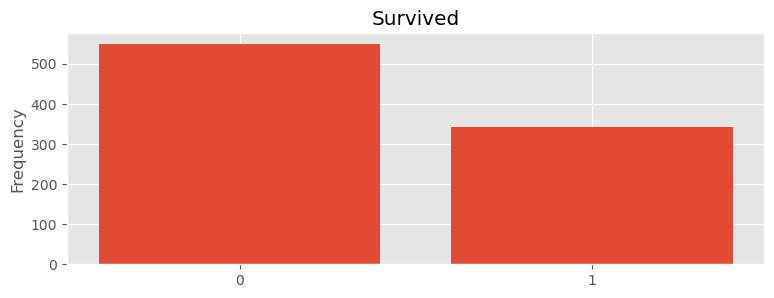

Survived: 
 Survived
0    549
1    342
Name: count, dtype: int64


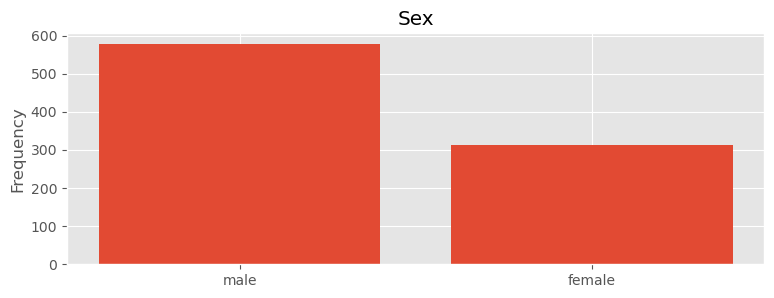

Sex: 
 Sex
male      577
female    314
Name: count, dtype: int64


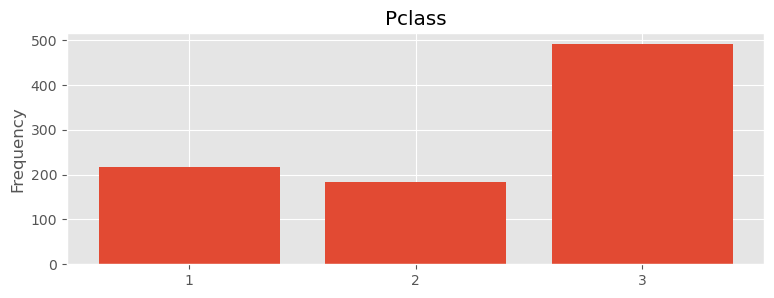

Pclass: 
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


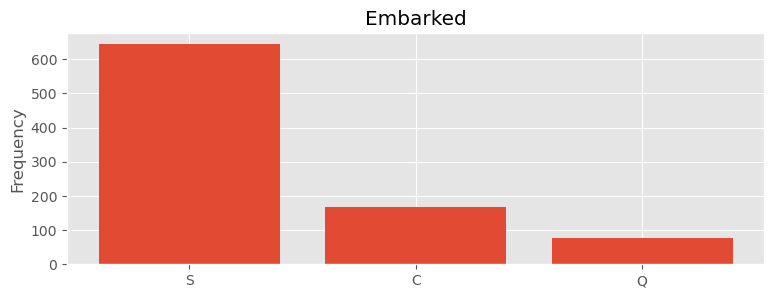

Embarked: 
 Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


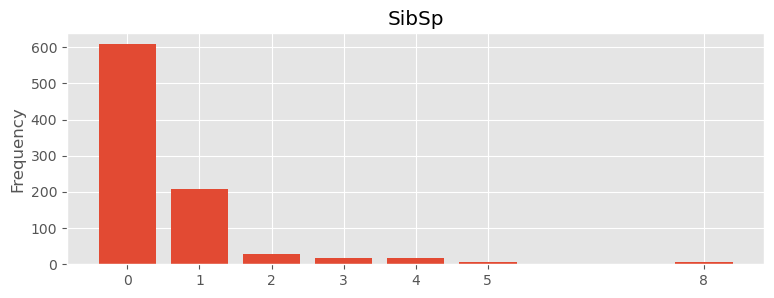

SibSp: 
 SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


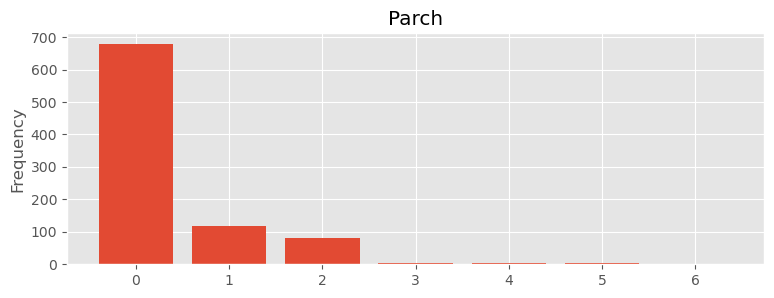

Parch: 
 Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [29]:
category1 = ["Survived","Sex","Pclass","Embarked","SibSp", "Parch"]
for c in category1:
    bar_plot(c)

- pclass içim 1 en zengim 2 orta 3 fakir
- survived için dengeli bir veri seti değil
- pclass ile embarked ilişkilendirilebilir


In [32]:
#cabin name be ticketı yukarda görselleştirmedik daha karışık çünkü


In [34]:
category2 = ["Cabin", "Name", "Ticket"]
for c in category2:
    print("{} \n".format(train_df[c].value_counts()))

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64 

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64 

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64 



## Numerical Variable

In [37]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(train_df[variable], bins = 50) # bins 800 olsa her bir yolcu içim yaparız 
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()
# bu metotu kullancaz

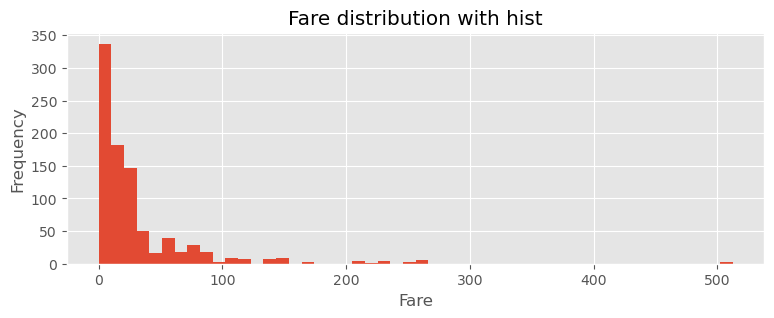

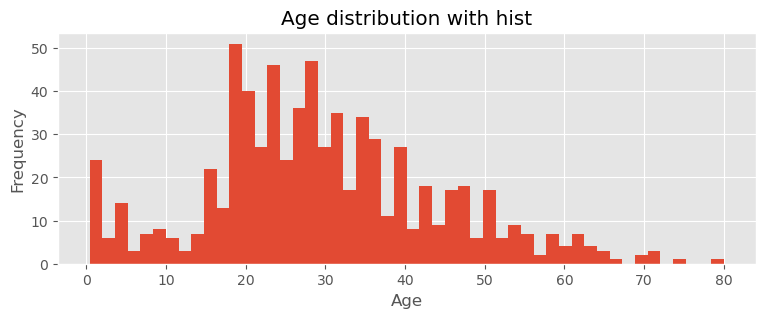

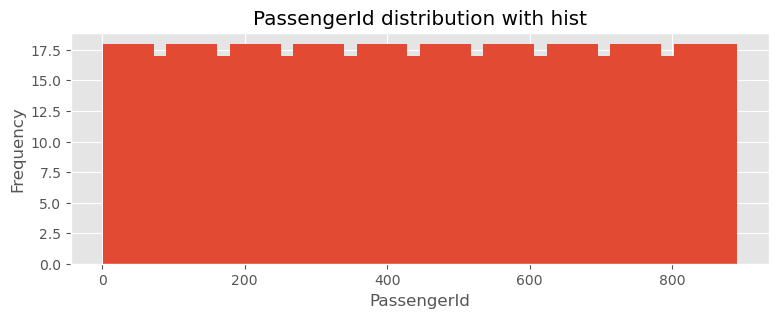

In [39]:
numericVar = ["Fare", "Age","PassengerId"]
for n in numericVar:
    plot_hist(n)

In [40]:
# passenger ıd bizim için önemli bir parametre değil 
#fare da 500 dolar ödeyen kişi ya çok iyi odaya sahip ya da başkalarının odasını da ödemiştir.


# Basic Data Analysis
* Pclass - Survived
* Sex - Survived
* SibSp - Survived
* Parch - Survived
* featurların ikili ilişkilerini incelicez bu kısımda

In [44]:
train_df[["Pclass","Survived"]]

,Pclass,Survived
0,3,0
1,1,1
2,3,1
3,1,1
4,3,0
...,...,...
886,2,0
887,1,1
888,3,0
889,1,1


In [46]:
# Plcass vs Survived
train_df[["Pclass","Survived"]].groupby(["Pclass"], as_index = False).mean().sort_values(by="Survived",ascending = False)
# sort.values() ile azalan bir sırada sıraladık 

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [48]:
# Zenginler daha fazla hayatta kalmış sonucuna ulaştık.

In [50]:
# Sex vs Survived
train_df[["Sex","Survived"]].groupby(["Sex"], as_index = False).mean().sort_values(by="Survived",ascending = False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [52]:
# kadınların erkeklere göre hayatta kalma olasılıkları çok daha fazladır.
# 1. sınıfta kalan bir kadının hayatta kalma olasığı daha da yüksektir.
# machine learning modeli de bunları öğrenecek

In [54]:
# Sibsp vs Survived
train_df[["SibSp","Survived"]].groupby(["SibSp"], as_index = False).mean().sort_values(by="Survived",ascending = False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [56]:
# Buraya 2 değeri için bir threshold koyulup 2 , 1 ve 0 'ın hayatta kalma oranı yüksek 2 üstünün ise düşük denebilir.

In [58]:
# Parch vs Survived
train_df[["Parch","Survived"]].groupby(["Parch"], as_index = False).mean().sort_values(by="Survived",ascending = False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [60]:
# parch ve sibsb'den yeni bir feature çıkarıp modelimizde kullanabiliriz.

# Outlier Detection
- Modeli düzgün eğitmek için aykırı değerlerden kurtulmak gerekir.
- Elimizde olan veriyi istatistiksel olarak bozan verilere outlier diyebiliriz.
- 1,4,5,6,8,9,11,12,13,14,15,16,17,100  median değeri yani q2 = 11.5 q1=6 q3=15  ıqr=15-6=9
- 9*1.5 = 13.5   6-13.5= -7.5  15+13.5 = 28.5  bu aralık dışındaki sayılar outlierdır. -7.5<x<28.5
- Outlier : 100
- Eğitilecek olan model outlierlar tarafından bozulmamalıdır.


In [63]:
def detect_outliers(df,features):
    outlier_indices = []
    
    for c in features:
        # 1st quartile
        Q1 = np.percentile(df[c],25)
        # 3rd quartile
        Q3 = np.percentile(df[c],75)
        # IQR
        IQR = Q3 - Q1
        # Outlier step
        outlier_step = IQR * 1.5
        # detect outlier and their indeces
        outlier_list_col = df[(df[c] < Q1 - outlier_step) | (df[c] > Q3 + outlier_step)].index
        # store indeces
        outlier_indices.extend(outlier_list_col)
    
    outlier_indices = Counter(outlier_indices) # bununla hangi yolcu birden fazla outlier içeriyor ya da kaç tane outlier içeriyor onu öğrenebilirim.
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2)
    
    return multiple_outliers

In [65]:
# bu metodu kullanarak outlierları içinde bulunduran bir datafrae elde etmiş oluruz. 
#.index ile de indeksini alabiliriz. indeksler outlier_indices içinde  depolanır.
#outlier tek bir feature da ise onu çıkarmak çok da mantıklı değildir.
# 2den fazla 3ten fazla feature da outlier varsa o yolcu o zaman çıkarılır.

In [67]:
a=["a","a","a","a","a","a","b","b","b"]
Counter(a)

Counter({'a': 6, 'b': 3})

In [69]:
#outlier drop edilecek. Fonksiyon içine train df alacak ve outlierları tespit etmek istedğim featurları yazıcam

In [71]:
train_df.loc[detect_outliers(train_df,["Age","SibSp","Parch","Fare"])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.00,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.00,C23 C25 C27,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.00,C23 C25 C27,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [73]:
# drop outliers
train_df = train_df.drop(detect_outliers(train_df,["Age","SibSp","Parch","Fare"]),axis = 0).reset_index(drop = True) 
# axis=0 ile satırları sildik ve outlierları  drop ettik
# indexleri de resetledik

# Missing Value
* Find Missing Value
* Fill Missing Value
* Missing valuedan nasıl kurtulacağımıza ya da nasıl dolduracağımıza bakacağız

In [76]:
# train ve test dataframeini birleştirmemiz lazım çünkü sadece train missing value doldursak ya da silsek test de görünce hata verir.

In [78]:
train_df_len = len(train_df) # uzunluğunu kaydettik kullanıcaz
train_df = pd.concat([train_df,test_df],axis = 0).reset_index(drop = True)

In [80]:
# birden fazla kez run etme train+test+test+... gibi olur

In [82]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Find Missing Value

In [85]:
train_df.columns[train_df.isnull().any()]
# train df içinde missing value var mı ona baktık varsa hangi column da olduğunu tespit ettik.

Index(['Survived', 'Age', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [87]:
train_df.isnull().sum() # nerde olduğunu öğrendik şimdi de kaç tane olduğuna bakalım
#survived 418 değeri test veri setinden kaynaklı

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             256
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1007
Embarked          2
dtype: int64

In [89]:
# age bilgisine sonra bakıcaz. Cabin önemsiz. Embarked ,fare doldurcaz. survived da ml so

## Fill Missing Value
* Embarked has 2 missing value
* Fare has only 1
* Bunları veriden drop edebiliriz ancak veri kaybetmeyi çok sevmeyiz onun için dolduralım

In [92]:
train_df[train_df["Embarked"].isnull()] #hangileri olduğunu bulduk # parasına göre doldurabiliriz.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
60,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
821,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


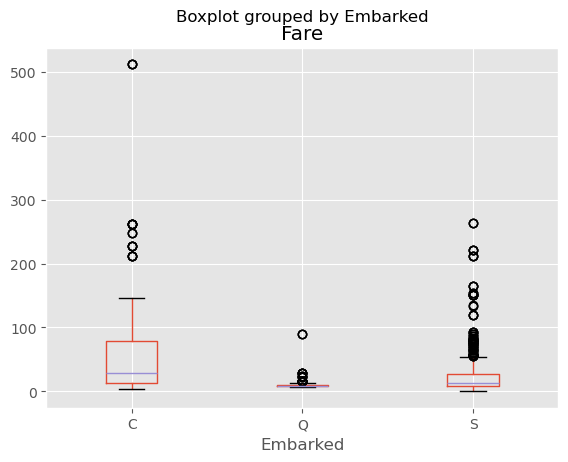

In [94]:
train_df.boxplot(column="Fare",by = "Embarked")
plt.show()
# q 3.sınıf s 2.sınıf c 1.sınıf gibi duruyor  . Parasında göre sınıfını bulmaya çalışıoruz

In [96]:
train_df["Embarked"] = train_df["Embarked"].fillna("C") # boş olanları c ile doldurduk
train_df[train_df["Embarked"].isnull()] # herhangi bir boş alan kalmadı

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [98]:
train_df[train_df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1033,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [100]:
np.mean(train_df[train_df["Pclass"]==3]["Fare"])

12.741219971469329

In [102]:
train_df["Fare"] = train_df["Fare"].fillna(np.mean(train_df[train_df["Pclass"] == 3]["Fare"])) # s,nan, 3.sınıf

In [104]:
train_df[train_df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
